# 타이타닉 분석 실습

> 이 데이터를 코드로 다루기 위해 필요한 것들을 하나씩 공부했고,  
> 전체 과정을 완전히 이해한 단계는 아니지만 처음으로 데이터 분석의 한 사이클을 경험해보았다.

## 1. Selection (데이터 선택 및 이해)

분석을 위해 수집한 데이터를 불러오고 전체 구조와 컬럼 정보를 확인하였다.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
df = sns.load_dataset('titanic')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## 2. Preprocessing (데이터 전처리 준비 및 EDA)

다음으로 EDA(탐색적 데이터 분석)를 통해 데이터 분포와 특징을 확인하였다.

- 변수 구성, 데이터의 형태, 결측치 존재 여부 파악
- 승객의 성별, 나이, 객실 등급 등 주요 변수 분포 분석

In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


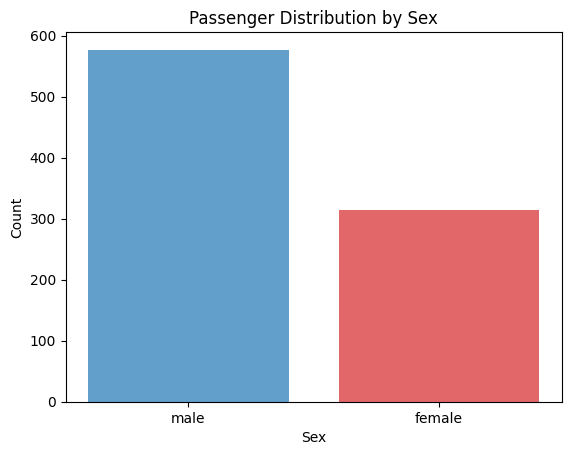

In [ ]:
sex_count = df['sex'].value_counts()

plt.bar(
    sex_count.index,
    sex_count.values,
    color=['tab:blue', 'tab:red'],
    alpha=0.7
)

plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Passenger Distribution by Sex')
plt.show()

## 3. Transformation (데이터 변환 및 관계 분석)

Heatmap을 통해 변수 간 상관관계를 분석하고 생존과 관련성이 높은 변수를 확인하였다.

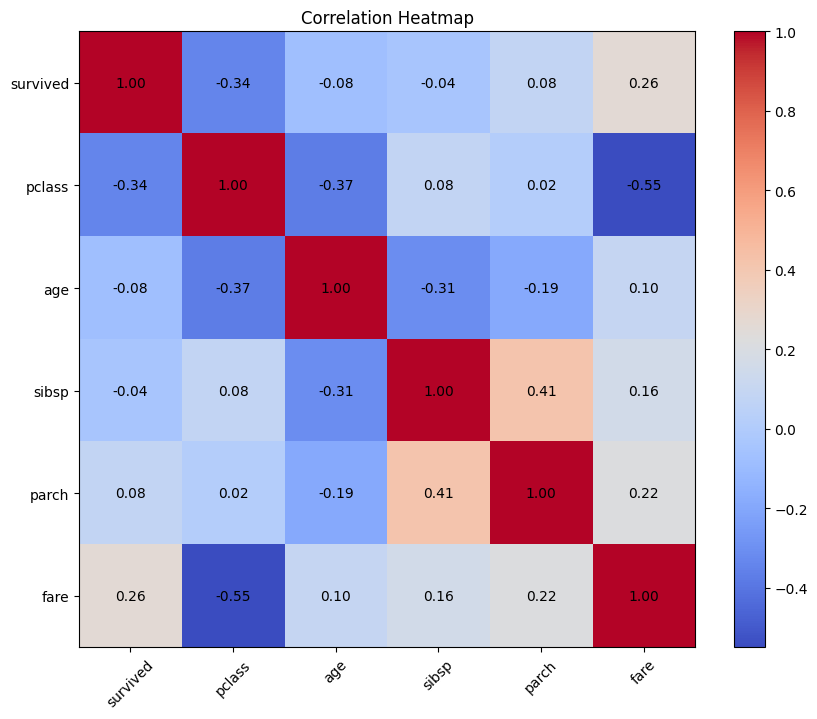

In [ ]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}',
                 ha = 'center',
                 va = 'center')

plt.title('Correlation Heatmap')
plt.show()

## 4. Data Mining (모델 학습)

Logistic Regression을 사용하여 생존 여부를 예측하는 모델을 학습하였다.
데이터를 기반으로 생존 확률을 추정하는 이진 분류 문제로 정의하였다.

In [ ]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']

X = df[features]
y = df['survived']

In [ ]:
X = pd.get_dummies(X, columns=['sex'], drop_first=True)

In [ ]:
X['age'] = X['age'].fillna(X['age'].median())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [ ]:
model = LogisticRegression(max_iter = 1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 5. Interpretation / Evaluation (결과 해석 및 평가)

학습된 모델을 기반으로 생존 여부를 예측하고 결과를 확인하였다.

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', accuracy)

Accuracy: 0.8044692737430168
